# Experiment 2 — ORS and $R_{\rm eff}$ Scaling

## Overview

This experiment tests the central hypothesis of the project:

> **High \(\Lambda\) (expressivity) is necessary but not sufficient for good QRC/QELM performance. The binding constraint is \(R_{\mathrm{eff}}\) (effective rank of the feature matrix).**

We sweep three circuit families — G1, G2, G3 (gate-based) and D2_random (IQP-style) — over a range of depths/degrees for qubit sizes \(n \in \{6, 8, 10, 12\}\). For each configuration we compute:
- **\(\Lambda\)** (ORS) — expressivity diagnostic.
- **\(R_{\mathrm{eff}}\)** — participation ratio of singular values of the centred feature matrix \(F_{\mathrm{centred}}\):
  $$R_{\mathrm{eff}}(F) = \frac{\left(\sum_k \sigma_k^2\right)^2}{\sum_k \sigma_k^4}.$$
- **\(\mathrm{Var}_x\)** — input-induced output variance (empirical variance of observable expectations over the input distribution).
- **MSE** on QELM (sine regression) and QRC (NARMA-5) tasks.

Tasks use the **Fourier \(s_k\)** input encoding throughout this experiment.

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import Ridge
from QELM import QuantumCircQiskit
from QRC import  QuantumRC_Circuit

from tqdm import tqdm
from metrics import (
    lorentz_curves,
    order_statistics_score,
    lambda_haar_exact,
    lambda_haar_largeD
)

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from qiskit.quantum_info import SparsePauliOp

# ── Target function ──────────────────────────────────────────────
def generate_target(x, n_a=6, seed=0):
    rng = np.random.default_rng(seed)
    K = (3**n_a - 1) // 2
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    y = np.zeros_like(x)
    for k in range(K + 1):
        y += a[k] * np.cos(k * x) + b[k] * np.sin(k * x)
    return y

In [84]:
LOAD_QELM  = True
QELM_DIR   = os.path.join("results", "exp2", "qelm", "sine")
os.makedirs(QELM_DIR, exist_ok=True)

n_list         = [6, 8, 10, 12]
ns_qelm        = 10
n_samples_qelm = 5000
train_frac     = 0.7       # → 3500 train / 1500 test
nshots_ors     = 2000
K_ors          = 4

# Sweep matrix (hp_kwargs keys match QuantumCircQiskit constructor exactly)
FAMILIES = {
    'Haar':            [{}],
    'G1':              [{'num_gates': ng} for ng in [10, 25, 50, 100, 200, 1000]],
    'G2':              [{'num_gates': ng} for ng in [10, 25, 50, 100, 200, 1000]],
    'G3':              [{'num_gates': ng} for ng in [10, 25, 50, 100, 200, 1000]],
    'D2_random':       [{'degree': d} for d in [1, 2, 4, 6, 10]],
    'D2_random_XZ':    [{'degree': d} for d in [1, 2, 4, 6, 10]],
    'D2_random_XZY':    [{'degree': d} for d in [1, 2, 4, 6, 10]],
}
# Total: 4 + 3*6*4 + 2*5*4 + 4 = 120 configs

print(f"n_list={n_list}, ns={ns_qelm}, n_samples={n_samples_qelm}, "
      f"train/test split={train_frac}/{1 - train_frac}")

n_list=[6, 8, 10, 12], ns=10, n_samples=5000, train/test split=0.7/0.30000000000000004


In [85]:
from sklearn.preprocessing import MinMaxScaler

# ── Data generation (fixed across all n) ─────────────────────────────────────────
rng   = np.random.default_rng(42)
x_all = rng.uniform(0, 2 * np.pi, n_samples_qelm)
y_all = generate_target(x_all, n_a=4, seed=0)

n_train  = int(n_samples_qelm * train_frac)   # 3500

idx_tr_s, idx_te_s = train_test_split(
    np.arange(n_samples_qelm), test_size=0.3, random_state=42)
y_train, y_test = y_all[idx_tr_s], y_all[idx_te_s]
x_train, x_test = x_all[idx_tr_s], x_all[idx_te_s]

scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test = scaler.transform(y_test.reshape(-1,1)).flatten()


print(f"x_train: {x_train.shape}  x_test: {x_test.shape}")
print(f"y range: [{y_train.min():.3f}, {y_train.max():.3f}]")

x_train: (3500,)  x_test: (1500,)
y range: [0.000, 1.000]


## Step 1: Imports and Pauli Observable Pool

We set up a pool of random Pauli observables (Pauli strings of weight 1 and 2) that will be measured for each circuit. The pool size `nobs` is fixed at 1000 — large enough that \(R_{\mathrm{eff}}\) saturates and is no longer sensitive to which observables are included.

In [86]:
# ── Random Pauli observables ─────────────────────────────────────
def random_pauli_observables(n_obs, n_qubits, seed=42):
    rng = np.random.default_rng(seed)
    paulis = np.array(['I', 'X', 'Y', 'Z'])
    return [SparsePauliOp(''.join(rng.choice(paulis, size=n_qubits)))
            for _ in range(n_obs)]

## Step 2: Single-Circuit Example — Feature Visualization

To build intuition, we run a single G3 circuit at a fixed depth and visualise the first few feature dimensions (observable expectations over \(n_{\mathrm{samples}}\) inputs). This illustrates what the raw feature matrix looks like before the systematic sweep.

In [87]:
n_samples_s = 5000
n_a_sine    = 6
max_n_obs = 1000


# ── Data ─────────────────────────────────────────────────────────────────────────────
x_sine  = np.linspace(0, 2 * np.pi, n_samples_s, endpoint=False)
y_sine  = generate_target(x_sine, n_a=n_a_sine, seed=0)

idx_tr_s, idx_te_s = train_test_split(
    np.arange(n_samples_s), test_size=0.3, random_state=42)
y_tr_s, y_te_s = y_sine[idx_tr_s], y_sine[idx_te_s]
x_tr_s, x_te_s = x_sine[idx_tr_s], x_sine[idx_te_s]

# ── Shared observable pool (random Pauli strings, same pool as above) ─────────
all_obs_sine = random_pauli_observables(max_n_obs, n_a_sine, seed=42)


In [88]:
qrc_e2 = QuantumCircQiskit(
            'Haar', nqbits=n_a_sine, encoding='exponential',
            k_exp=n_a_sine, theta_scale=1.0, statevector=True,
            observables_type=all_obs_sine)

fe_tr2 = qrc_e2.feature_matrix(x_tr_s)
fe_te2 = qrc_e2.feature_matrix(x_te_s)

lm_e2 = LinearRegression().fit(fe_tr2, y_tr_s)
ye2 = lm_e2.predict(fe_te2)
mse2 = np.mean((ye2 - y_te_s)**2)
print( mse2)

3.1801336241971813e-25


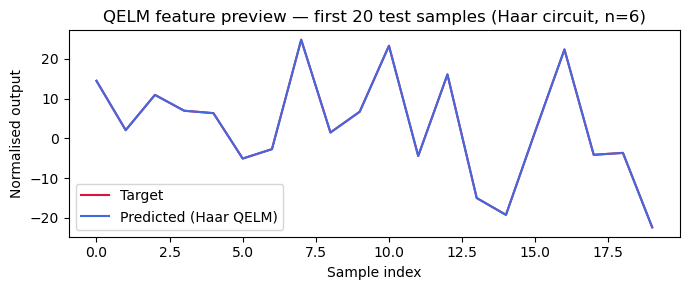

In [89]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(y_te_s[:20], color='crimson', label='Target')
ax.plot(ye2[:20], color='royalblue', label='Predicted (Haar QELM)')
ax.set_xlabel('Sample index')
ax.set_ylabel('Normalised output')
ax.set_title('QELM feature preview — first 20 test samples (Haar circuit, n=6)')
ax.legend()
fig.tight_layout()
plt.show()

## Step 3: Effective-Rank and Var_x Helpers

These functions compute the two diagnostic metrics:
- **`effective_rank(F)`** — computes \(R_{\mathrm{eff}}\) from the singular values of the centred feature matrix. Only singular values above \(10^{-12}\) are counted (suppresses numerical noise).
- **Observable count helpers** — bookkeeping for how many observables are active at each qubit count.

In [ ]:
from matplotlib.ticker import ScalarFormatter, NullLocator

# ─────────────────────────────────────────────────────────────────────
# ORS references and D-only multibasis loader
# ─────────────────────────────────────────────────────────────────────

ors_Haar = np.load("results/ors/small_n/Haar_100runs.npz")

ORS_BASIS_DIR = os.path.join("results", "ors", "basis")
D2_FAMILIES_MB = ["D2_random", "D2_random_XZ", "D2_random_XZY"]


def _ors_haar_value(n, K_idx=1):
    return ors_Haar[f"lambda_haar_n{int(n)}"][K_idx]


def _d2_mb_file(family, degree, ns=10):
    return os.path.join(
        ORS_BASIS_DIR,
        f"{family}_deg{int(degree)}_L1_{ns}runs_multibasis.npz",
    )


def _mb_kidx(data, K_mb):
    K_list = list(data["K_ors"])
    if K_mb not in K_list:
        raise ValueError(f"K_mb={K_mb} not available. Found K_ors={K_list}")
    return K_list.index(K_mb)


def load_d2_neg_multibasis_ors(family, degree, n_ors, K_mb=8, B=5, ns=10):
    """
    D-family ORS replacement:
        -mean(gap_X, gap_Y, gap_Z, gmb_B5)

    The output is already a gap-to-Haar diagnostic, so the Haar reference is 0.
    """
    path = _d2_mb_file(family, degree, ns=ns)

    if not os.path.exists(path):
        print(f"Missing multibasis ORS file: {path}")
        return np.nan, np.nan

    data = np.load(path)
    kidx = _mb_kidx(data, K_mb)

    keys = [
        f"gap_X_n{int(n_ors)}",
        f"gap_Y_n{int(n_ors)}",
        f"gap_Z_n{int(n_ors)}",
        f"gmb_B{int(B)}_n{int(n_ors)}",
    ]
    num_vals = {f"gap_X_n{int(n_ors)}": 1,
        f"gap_Y_n{int(n_ors)}": 1,
        f"gap_Z_n{int(n_ors)}": 1,
        f"gmb_B{int(B)}_n{int(n_ors)}": B,}

    missing = [k for k in keys if k not in data.files]
    if missing:
        print(f"Missing keys in {path}: {missing}")
        return np.nan, np.nan

    gaps = np.array([np.abs(data[k][kidx])*num_vals[k] for k in keys], dtype=float)

    mean = -np.sum(gaps) / ( B + 3)
    sem = gaps.std(ddof=1) /( B + 3)
    return np.max(np.array([np.abs(data[k][kidx]) for k in keys], dtype=float)), sem #mean, sem


def load_d2_neg_multibasis_curve(family, degrees, n_ors, K_mb=8, B=5, ns=10):
    means, sems = [], []

    for degree in degrees:
        m, s = load_d2_neg_multibasis_ors(
            family=family,
            degree=degree,
            n_ors=n_ors,
            K_mb=K_mb,
            B=B,
            ns=ns,
        )
        means.append(m)
        sems.append(s)

    return np.array(means), np.array(sems)

In [91]:
# ── Observable count helpers ──────────────────────────────────────────────────────
def _total_obs(n):
    """Number of 1+2-local Pauli observables on n qubits: 3n + 9*C(n,2)."""
    return 3 * n + 9 * (n * (n - 1) // 2)

def _n_obs_list(n):
    total = _total_obs(n)
    return np.unique(np.geomspace(10, total, num=10).astype(int))


# ── Path scheme ───────────────────────────────────────────────────────────────────
def _qelm_path(family, n, ns, **hp_kwargs):
    _abbrev = {'num_gates': 'ng', 'degree': 'deg', 'dt': 'dt'}
    tag = family
    for k, v in sorted(hp_kwargs.items()):
        tag += f"_{_abbrev.get(k, k)}{v}"
    return os.path.join(QELM_DIR, f"{tag}_{n}q_{ns}runs.npz")


# ── Save / load ───────────────────────────────────────────────────────────────────
def _save_qelm(path, ors, var_x, mse, R_eff):# feat_train, feat_test,
    np.savez_compressed(path,
        ors=ors,               # (ns,)
        var_x=var_x,           # (ns, n_obs_full)
    #    feat_train=feat_train, # (ns, n_train, n_obs_full)
    #    feat_test=feat_test,   # (ns, n_test,  n_obs_full)
        mse=mse,               # (ns, len(n_obs_list))
        R_eff=R_eff,           # (ns, len(n_obs_list))
    )
    print(f"  Saved → {path}")

def _load_qelm(path):
    d = np.load(path, allow_pickle=False)
    return d['ors'], d['var_x'], d['mse'], d['R_eff'] #d['feat_train'], d['feat_test'], d['mse'], d['R_eff']


# ── Smoke-check ───────────────────────────────────────────────────────────────────
print("Observable counts per n:")
for _n in [6, 8, 10, 12]:
    print(f"  n={_n}: total={_total_obs(_n)}, n_obs_list={_n_obs_list(_n)}")

Observable counts per n:
  n=6: total=153, n_obs_list=[ 10  13  18  24  33  45  61  83 112 153]
  n=8: total=276, n_obs_list=[ 10  14  20  30  43  63  91 132 190 276]
  n=10: total=435, n_obs_list=[ 10  15  23  35  53  81 123 188 286 435]
  n=12: total=630, n_obs_list=[ 10  15  25  39  63  99 158 250 397 630]


In [92]:
# ── effective_rank ────────────────────────────────────────────────────────────────
def effective_rank(F, eps=1e-12):
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        # Fall back to scipy's gesvd driver
        from scipy.linalg import svd
        sv = svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return sv.sum()**2 / (sv**2).sum()

def add_shot_noise_proper(F, n_shots=1024, rng=None):
    """
    Simulate finite-shot measurement of expectation values for Pauli observables.
    F: shape (N, n_obs), values in [-1, +1].
    Each F[i, j] gets independent Gaussian noise with σ = √((1 - F[i,j]²)/n_shots).
    """
    rng = rng or np.random.default_rng(0)
    sigma = np.sqrt(np.maximum(0, 1 - F**2) / n_shots)
    return F + rng.normal(0, 1, F.shape) * sigma


# ── run_qelm_experiment ───────────────────────────────────────────────────────────
def run_qelm_experiment(gates_name, n, ns, x_train, x_test, y_train, y_test, add_noise = False, shots = 1024,
                         **circuit_kwargs):
    """
    Runs ns random reservoir instances for the QELM sine task (exponential encoding).

    circuit_kwargs: reservoir-only params forwarded to QuantumCircQiskit
                    (num_gates, degree, dt, n_layers, scrambler_depth, …)

    Returns
    -------
    ors        : (ns,)
    var_x      : (ns, n_obs_full)
    feat_train : (ns, n_train, n_obs_full)
    feat_test  : (ns, n_test,  n_obs_full)
    mse        : (ns, len(n_obs_list))
    R_eff      : (ns, len(n_obs_list))
    """
    #nobs_list = _n_obs_list(n)

    ors_list        = []
    var_x_list      = []
    feat_train_list = []
    feat_test_list  = []
    mse_list        = []
    R_eff_list      = []

    # ── Shared observable pool (random Pauli strings, same pool as above) ─────────
    all_obs_sine = random_pauli_observables(1000, n, seed=42)
    nobs_list = np.arange(10, 1100, 100)

    for run in tqdm(range(ns), desc=f"{gates_name} n={n}"):
        seed = run * 2

        # ── ORS (Λ): reservoir output distribution, no encoding/observable layer ─
        np.random.seed(seed)
        _tmp = QuantumCircQiskit(gates_name, nqbits=n, statevector=True, **circuit_kwargs)
        _, sorted_probs, _ = lorentz_curves(_tmp.get_reservoir, n, nshots_ors, 1,
                                            verbose=False)
        lam = order_statistics_score(sorted_probs, 2**n, K=K_ors)[0]
        ors_list.append(lam)

        # ── Feature matrix: same seed → same reservoir + obs + exponential encoding
        np.random.seed(seed)
        qrc = QuantumCircQiskit(
            gates_name, nqbits=n, theta_scale = 1.0,
            observables_type=all_obs_sine,#[1, 2],
            encoding='exponential', k_exp=6,
            statevector=True,
            **circuit_kwargs
        )

        F_train = qrc.feature_matrix(x_train)   # (n_train, n_obs_full)
        F_test  = qrc.feature_matrix(x_test)    # (n_test,  n_obs_full)

        if add_noise:
            F_train = add_shot_noise_proper(F_train, n_shots = shots)
            F_test = add_shot_noise_proper(F_test, n_shots = shots)

        var_x_list.append(np.var(F_train, axis=0))   # input-induced variance per obs
        feat_train_list.append(F_train)
        feat_test_list.append(F_test)

        # ── n_obs sweep: column-truncate, no rebuild ──────────────────────────────
        mse_run   = []
        R_eff_run = []
        for nobs in nobs_list:
            Ft = F_train[:, :nobs]
            Fv = F_test[:, :nobs]
            ridge = LinearRegression()
            ridge.fit(Ft, y_train)
            mse_run.append(np.mean((ridge.predict(Fv) - y_test) ** 2))
            R_eff_run.append(effective_rank(Ft))

        mse_list.append(mse_run)
        R_eff_list.append(R_eff_run)

    print(f'Mean Var_x = {np.mean(var_x_list):.6f}, mean R_eff = {np.mean(np.array(R_eff_list)[:, -1]):.6f}, mean MSE = {np.mean(np.array(mse_list)[:, -1]):.16f}, ORS = {np.mean(ors_list):.2f}')

    return (
        np.array(ors_list),
        np.array(var_x_list),
       # np.array(feat_train_list),
       # np.array(feat_test_list),
        np.array(mse_list),
        np.array(R_eff_list),
    )

print("effective_rank and run_qelm_experiment defined.")

effective_rank and run_qelm_experiment defined.


In [111]:
# ── Sweep loop ────────────────────────────────────────────────────────────────────
results = {}   # keyed by (family, frozenset(hp_kwargs.items()), n)

for n in [6]:#n_list:
    for gates_name, hp_list in FAMILIES.items():
        for hp_kwargs in hp_list:
            key  = (gates_name, frozenset(hp_kwargs.items()), n)
            path = _qelm_path(gates_name, n, ns_qelm, **hp_kwargs)

            if LOAD_QELM and os.path.exists(path):
                results[key] = _load_qelm(path)
                print(f"Loaded {path}")
            else:
                res = run_qelm_experiment(
                    gates_name, n, ns_qelm,
                    x_train, x_test, y_train, y_test,
                    **hp_kwargs
                )
                _save_qelm(path, *res)
                results[key] = res
                print(f"Saved  {path}")

print(f"\nDone. {len(results)} configs in memory.")

Loaded results\exp2\qelm\sine\Haar_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng10_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng25_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng50_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng100_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng200_6q_10runs.npz
Loaded results\exp2\qelm\sine\G1_ng1000_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng10_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng25_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng50_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng100_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng200_6q_10runs.npz
Loaded results\exp2\qelm\sine\G2_ng1000_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng10_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng25_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng50_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng100_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng200_6q_10runs.npz
Loaded results\exp2\qelm\sine\G3_ng1000_6q_10runs.npz
Loa

### Sweep Progress Log

The cell above runs the full parameter sweep (families × depths × qubit sizes × tasks). Results are cached to disk and loaded on subsequent runs. This section logs progress and any cache hits/misses.

In [112]:
# ─────────────────────────────────────────────────────────────────────
# Style
# ─────────────────────────────────────────────────────────────────────
 
FAMILY_COLORS = {
    'Haar':           '#000000',
    'G1':             'royalblue',
    'G2':             'mediumseagreen',
    'G3':             'crimson',
    'D2_random':      '#9467bd',
    'D2_random_XZ':   '#e377c2',
    'D2_random_XZY':  'tab:orange',
}
 
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}
 
# ─────────────────────────────────────────────────────────────────────
# Helpers: unpack the tuple-keyed results dict
# ─────────────────────────────────────────────────────────────────────
def _hp_dict(hp_frozenset):
    return dict(hp_frozenset)
 
 
def get_complexity(family, hp_frozenset):
    """Return the family's tunable hyperparameter value (depth or degree)."""
    key = COMPLEXITY_KEY.get(family)
    if key is None:
        return None
    return _hp_dict(hp_frozenset).get(key)
 
 
def iter_results(results, family=None, n=None):
    """Yield (family, hp_frozenset, n, ors, var_x, mse, R_eff) for matching entries."""
    for key, val in results.items():
        fam, hp_fs, n_val = key
        if fam in EXCLUDE:
            continue
        if family is not None and fam != family:
            continue
        if n is not None and n_val != n:
            continue
        ors, var_x, mse, R_eff = val
        yield fam, hp_fs, n_val, ors, var_x, mse, R_eff
 
 
def get_n_list(results):
    return sorted({k[2] for k in results.keys() if k[0] not in EXCLUDE})
 
 
def get_families(results):
    return sorted({k[0] for k in results.keys() if k[0] not in EXCLUDE})
 
 
def deepest_per_family(results, n):
    """For each family at this n, return the entry with maximum complexity."""
    out = {}
    for fam, hp_fs, n_val, ors, var_x, mse, R_eff in iter_results(results, n=n):
        c = get_complexity(fam, hp_fs)
        # Haar has no complexity knob; just take the (only) entry
        if c is None:
            out[fam] = (hp_fs, ors, var_x, mse, R_eff)
        else:
            if fam not in out or c > get_complexity(fam, out[fam][0]):
                out[fam] = (hp_fs, ors, var_x, mse, R_eff)
    return out

N_MARKERS = {6: 'o', 8: 's', 10: 'D', 12: '^'}
 
COMPLEXITY_KEY = {
    'Haar':          None,
    'G1':            'num_gates',
    'G2':            'num_gates',
    'G3':            'num_gates',
    'D2_random':     'degree',
    'D2_random_XZ':  'degree',
    'D2_random_XZY': 'degree',
}
 
# Family groups for the two-column layout
G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']
 
EXCLUDE = {'symmetric_Ising'}
 
# ORS lower cap: values below this are clipped for plotting. Captures the
# stabilizer-state pathology for G1/G2 without giving the impression Λ → -∞
# means "less expressive than Haar" — which is the wrong reading.
ORS_LOWER_CAP = -60.0
MSE_FLOOR     = 1e-15   # values below this are clipped to this value
 
# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def collect_curve(results, family, n, metric,
                  ors_cap=ORS_LOWER_CAP, mse_floor=MSE_FLOOR):
    """
    Return (complexity_vals, mean, sem) arrays for one (family, n) curve.
 
    metric ∈ {'ors', 'R_eff', 'mse'}.
    """
    points = []
    for fam, hp_fs, n_val, ors, var_x, mse, R_eff in iter_results(
            results, family=family, n=n):
        c = get_complexity(fam, hp_fs)
        if c is None:
            continue
        if metric == 'ors':
            vals = ors
            if ors_cap is not None:
                vals = np.clip(vals, ors_cap, None)
        elif metric == 'R_eff':
            vals = R_eff[:, -1]
        elif metric == 'mse':
            vals = mse[:, -1]
            if mse_floor is not None:
                vals = np.clip(vals, mse_floor, None)
        else:
            raise ValueError(metric)
        ns = len(vals)
        m = float(np.mean(vals))
        s = float(np.std(vals) / ns) if ns > 1 else 0.0
        points.append((c, m, s))
    if not points:
        return np.array([]), np.array([]), np.array([])
    points.sort(key=lambda t: t[0])
    cs = np.array([p[0] for p in points])
    ms = np.array([p[1] for p in points])
    ses = np.array([p[2] for p in points])
    return cs, ms, ses
 
 
def haar_reference(results, n, metric,
                   ors_cap=ORS_LOWER_CAP, mse_floor=MSE_FLOOR):
    """Return mean for Haar at this n, for the given metric."""
    for fam, hp_fs, n_val, ors, var_x, mse, R_eff in iter_results(
            results, family='Haar', n=n):
        if metric == 'ors':
            vals = ors
            if ors_cap is not None:
                vals = np.clip(vals, ors_cap, None)
        elif metric == 'R_eff':
            vals = R_eff[:, -1]
        elif metric == 'mse':
            vals = mse[:, -1]
            if mse_floor is not None:
                vals = np.clip(vals, mse_floor, None)
        return float(np.mean(vals))
    return None
 

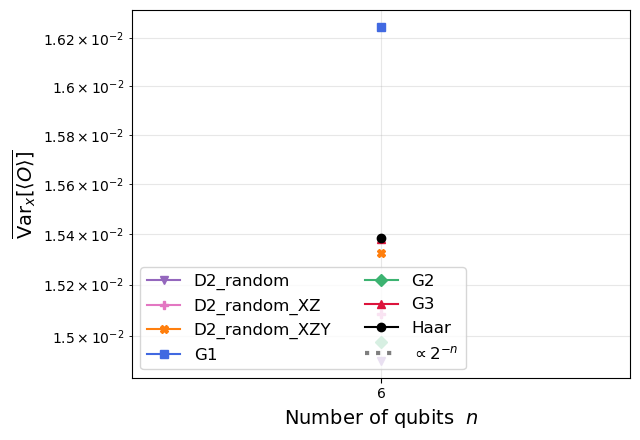

In [113]:
# ─────────────────────────────────────────────────────────────────────
# Figure 1: Var_x vs n  (concentration is universal)
# ─────────────────────────────────────────────────────────────────────
def fig1_var_x_scaling(results, save_path='fig1_var_x_scaling.png'):
    """Mean Var_x vs n for each family (deepest variant). Reference: 2^{-n}."""
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    n_list = get_n_list(results)
 
    for family in get_families(results):
        ns, vars_x = [], []
        for n in n_list:
            deepest = deepest_per_family(results, n)
            if family not in deepest:
                continue
            _, _, var_x, _, _ = deepest[family]
            ns.append(n)
            vars_x.append(float(np.mean(var_x)))
        if not ns:
            continue
        ax.semilogy(ns, vars_x,
                    marker=FAMILY_MARKERS.get(family, 'o'),
                    color=FAMILY_COLORS.get(family, '#888'),
                    label=family)
 
    # 2^{-n} reference anchored at Haar n=min
    n_min = min(n_list)
    haar_at_min = [d for d in deepest_per_family(results, n_min).items()
                   if d[0] == 'Haar']
    if haar_at_min:
        v0 = float(np.mean(haar_at_min[0][1][2]))   # var_x slot in tuple
        ns_ref = np.array(n_list)
        ax.semilogy(ns_ref, v0 * 2.0 ** (-(ns_ref - n_min)), 
                    'k:', lw = 3, alpha=0.5, label=r'$\propto 2^{-n}$')
 
    ax.set_xlabel('Number of qubits  $n$', fontsize = 14)
    ax.set_ylabel(r'$\overline{\mathrm{Var}_x[\langle O \rangle]}$', fontsize = 14)
    ax.set_xticks(n_list)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='lower left', ncol=2, fontsize = 12)
    fig.tight_layout()
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

fig1_var_x_scaling(results, save_path='fig1_var_x_scaling.png')

In [4]:
res = np.load('results/qelm/sine/D2_random_deg1_6q_100runs.npz')
res.keys()

KeysView(NpzFile 'results/qelm/sine/D2_random_deg1_6q_100runs.npz' with keys: mse_pauli, mse_exp, y_pred_pauli, y_pred_exp, n_obs_list...)

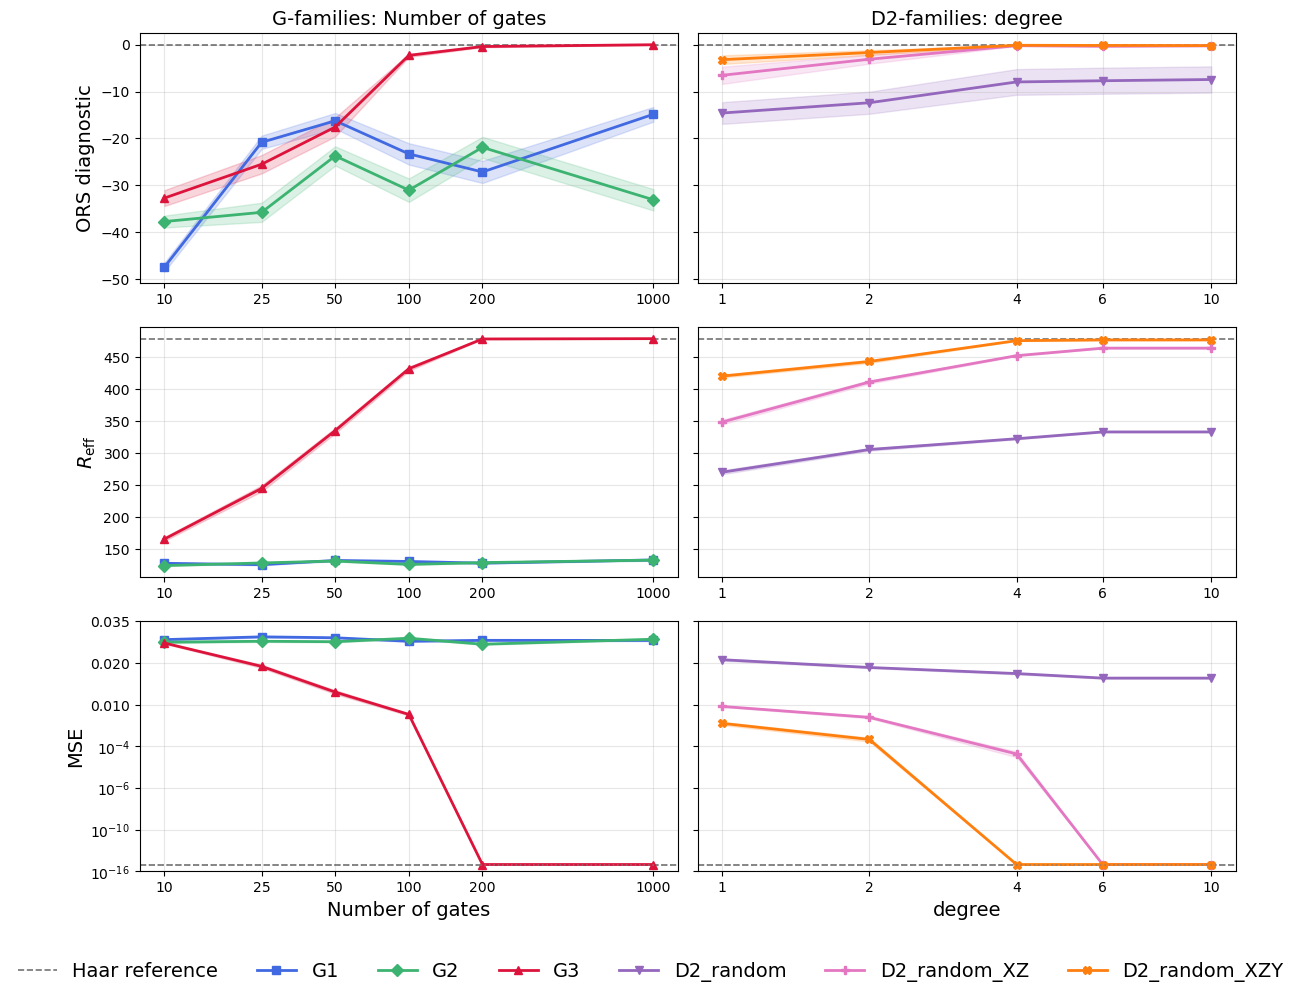

In [114]:
from matplotlib.ticker import ScalarFormatter, NullLocator

ors_Haar = np.load('results/ors/small_n/Haar_100runs.npz')
ors_Haar10 = ors_Haar['lambda_haar_n10'][1]

def fig2_diagnostics_at_n(
    results,
    n_target=10,
    save_path=None,
    ors_cap=ORS_LOWER_CAP,
    mse_floor=MSE_FLOOR,
    use_multibasis_for_D=True,
    n_ors_D=None,
    K_mb=8,
    B_mb=5,
):
    """
    Three rows (ORS, R_eff, MSE) × two columns (G-families | D2-families).

    G families:
        plot single-basis ORS gap Lambda - Lambda_Haar.

    D families:
        plot -mean(gap_X, gap_Y, gap_Z, gmb_B5).
    """
    if save_path is None:
        save_path = f"figures/fig2_diagnostics_n{n_target}_D_multibasis.png"

    if n_ors_D is None:
        n_ors_D = n_target

    ors_Haar_n = _ors_haar_value(n_target, K_idx=1)

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey="row")

    metrics = [
        ("ors",   r"ORS diagnostic", "linear"),
        ("R_eff", r"$R_{\rm eff}$",  "linear"),
        ("mse",   "MSE",             "linear"),
    ]

    col_families = [
        ("G-families: Number of gates", G_FAMILIES, "Number of gates"),
        ("D2-families: degree", D2_FAMILIES, "degree"),
    ]

    for row, (metric, ylabel, yscale) in enumerate(metrics):
        for col, (col_title, family_list, xlabel) in enumerate(col_families):
            ax = axes[row, col]

            href = haar_reference(results, n_target, metric, ors_cap, mse_floor) if metric != "ors" else 0
            if href is not None:
                ax.axhline(
                    href,
                    color=FAMILY_COLORS["Haar"],
                    ls="--",
                    alpha=0.55,
                    lw=1.2,
                    label="Haar reference" if (row == 0 and col == 0) else None,
                )

            last_cs = None

            for family in family_list:
                color = FAMILY_COLORS.get(family, "#888")
                marker = FAMILY_MARKERS.get(family, "o")

                cs, ms, ses = collect_curve(
                    results,
                    family,
                    n_target,
                    metric,
                    ors_cap,
                    mse_floor,
                )

                if len(cs) == 0:
                    continue

                if metric == "ors":
                    if use_multibasis_for_D and family in D2_FAMILIES_MB:
                        ms, ses = load_d2_neg_multibasis_curve(
                            family,
                            degrees=cs,
                            n_ors=n_ors_D,
                            K_mb=K_mb,
                            B=B_mb,
                        )
                    else:
                        ms = ms - ors_Haar_n

                    finite = np.isfinite(ms) & np.isfinite(ses)
                    cs, ms, ses = cs[finite], ms[finite], ses[finite]

                    if len(cs) == 0:
                        continue

                last_cs = cs

                ax.plot(
                    cs,
                    ms,
                    marker=marker,
                    color=color,
                    lw=2.0,
                    label=family if row == 0 else None,
                )

                ax.fill_between(
                    cs,
                    ms - ses,
                    ms + ses,
                    color=color,
                    alpha=0.18,
                )

            ax.set_xscale("log")

            if metric == "mse":
                TICKS = np.array([0.035, 0.020, 0.010, 1e-4, 1e-6, 1e-10, 1e-16])
                POSITIONS = np.arange(len(TICKS))
                log_ticks = np.log10(TICKS)

                def fwd(x):
                    lx = np.log10(np.clip(np.abs(x), 1e-30, None))
                    return np.interp(lx, log_ticks[::-1], POSITIONS[::-1])

                def inv(p):
                    lx = np.interp(p, POSITIONS, log_ticks)
                    return 10 ** lx

                ax.set_yscale("function", functions=(fwd, inv))
                ax.set_yticks(TICKS)
                ax.set_yticklabels(
                    [
                        f"{t:.3f}" if t >= 0.01 else f"$10^{{{int(np.log10(t))}}}$"
                        for t in TICKS
                    ]
                )
                ax.set_ylim(TICKS[0], TICKS[-1])

            elif yscale == "log":
                ax.set_yscale("log")

            ax.grid(True, which="both", alpha=0.3)

            if last_cs is not None:
                ax.set_xticks(last_cs)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            if row == 0:
                ax.set_title(col_title, fontsize=14)

            if row == 2:
                ax.set_xlabel(xlabel, fontsize=14)

            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

            if metric == "mse" and mse_floor is not None:
                ax.axhline(mse_floor, color="gray", ls=":", lw=1.2, alpha=0.7)

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=len(labels),
        fontsize=14,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
 
fig2_diagnostics_at_n(
    results,
    n_target=6,
    use_multibasis_for_D=True,
    n_ors_D=6,
    K_mb=4,
    B_mb=5,
)

## Step 4: QRC Diagnostics — NARMA Task with Fourier Encoding

We now run the same sweep (families × depths × qubit sizes) on the **NARMA-5 QRC task** with Fourier \(s_k\) encoding.

**NARMA-5**: \(y(k) = 0.3\,y(k-1) + 0.05\,y(k-1)\sum_{i=1}^{5} y(k-i) + 1.5\,u(k)\,u(k-5) + 0.1\)

This task requires non-linear processing of past inputs, making it sensitive to both expressivity and memory capacity. The Fourier encoding fixes the frequency budget \(\Omega\) so that differences in MSE are attributable to the reservoir, not the encoding.

In [101]:
def generate_narma_fourier_task(
    T=2000, n_train=1400, narma_order=5,
    n_a=6, seed=0, normalize=True, use_g = True,
):
    """
    NARMA-n task with Fourier-rich external input.
    
    The input to the QRC is u_t ∈ [0, 2π] (uniform random).
    The driver s_t = g(u_t) where g has frequencies matching the
    exponential encoding's budget for n_a qubits.
    The target y_{t+1} follows NARMA dynamics in s_t and past y.
    
    Parameters
    ----------
    T : int
        Total length of the time series.
    n_train : int
        Length of training set.
    narma_order : int
        NARMA memory depth. 5 is standard; 10 tests longer memory.
    n_a : int
        Encoding qubit count — determines g's frequency content.
    """
    rng = np.random.default_rng(seed)
    K = (3 ** n_a - 1) // 2  # 364 for n_a=6
    
    # Random Fourier coefficients for g
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    
    def g(u):
        """Fourier-rich driver function: g: [0, 2π] → R, with frequencies up to K."""
        u = np.atleast_1d(u)
        out = np.zeros_like(u, dtype=float)
        for k in range(K + 1):
            out += a[k] * np.cos(k * u) + b[k] * np.sin(k * u)
        return out
    
    
    # Normalize g to [0, 0.5] (NARMA expects s_t ∈ [0, 0.5])
    u_probe = np.linspace(0, 2 * np.pi, 5000)
    g_vals = g(u_probe) if use_g else u_probe
    g_min, g_max = g_vals.min(), g_vals.max()
    
    def g_normalized(u):
        if use_g:
            return 0.5 * (g(u) - g_min) / (g_max - g_min)
        return 0.5 * (u - g_min) / (g_max - g_min)
    
    # Generate input sequence u_t and driver s_t
    u = rng.uniform(0, 2 * np.pi, size=T)
    s = g_normalized(u)
    
    # Run NARMA dynamics: need narma_order burn-in steps
    y = np.zeros(T)
    n = narma_order
    for t in range(n - 1, T - 1):
        y[t + 1] = (0.3 * y[t] 
                    + 0.05 * y[t] * np.sum(y[t - n + 1:t + 1])
                    + 1.5 * s[t - n + 1] * s[t] 
                    + 0.1)
    
    # Drop burn-in
    u = u[n:]
    y = y[n:]
    T_eff = len(y)
    assert n_train < T_eff
    
    # QRC input: u_t (the reservoir sees u_t and must predict y_{t+1})
    # Target: y itself
    u = u.reshape(-1, 1)
    y = y.reshape(-1, 1)
    u_train, u_test = u[:n_train], u[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    
    scaler = None
    if normalize:
        # Scale the INPUT u to [0, 1] so the QRC encoding sees a standard range
        u_scaler = MinMaxScaler(feature_range=(0, 1))
        u_train = u_scaler.fit_transform(u_train)
        u_test = u_scaler.transform(u_test)
        # Scale the target separately
        y_scaler = MinMaxScaler(feature_range=(0, 1))
        y_train = y_scaler.fit_transform(y_train)
        y_test = y_scaler.transform(y_test)
        scaler = (u_scaler, y_scaler)
    
    return {
        'u_train': u_train, 'u_test': u_test,   # QRC inputs
        'y_train': y_train, 'y_test': y_test,   # targets
        'g': g_normalized,
        'K': K,
        'narma_order': narma_order,
        'scaler': scaler,
    }

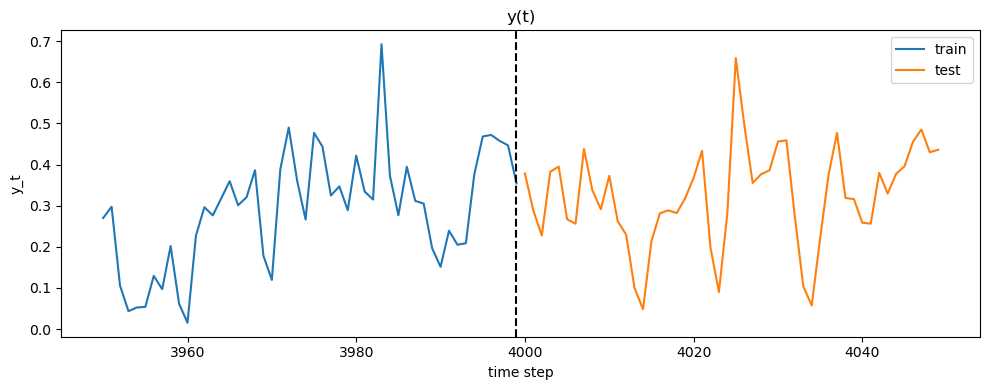

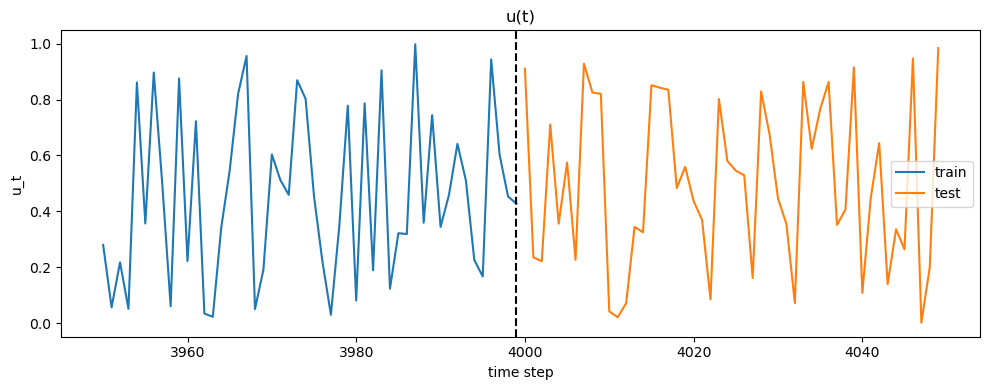

In [27]:
data = generate_narma_fourier_task(T=5000, n_train=4000, narma_order=2, n_a=3)
u_train, y_train = data['u_train'], data['y_train']
u_test, y_test = data['u_test'], data['y_test']
t_train = np.arange(len(y_train))
t_test = np.arange(len(y_train), len(y_train) + len(y_test))

plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], y_train[-50:], label="train")
plt.plot(t_test[:50], y_test[:50], label="test")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("y_t")
plt.title("y(t)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], u_train[-50:], label="train")
plt.plot(t_test[:50], u_test[:50], label="test")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("u_t")
plt.title("u(t)")
plt.legend()
plt.tight_layout()
plt.show()



In [102]:
# ── Gate-family comparison experiment ────────────────────────────────────────

QRC_DIR = os.path.join("results", "time_series", "NARMA")
os.makedirs(QRC_DIR, exist_ok=True)


# ── Persistence helpers ───────────────────────────────────────────────────────
def _qrc_path(gates_name, nqbits, ns, num_gates=None, degree=None,
              n_layers=None, scrambler_depth=None):
    tag = gates_name
    if num_gates       is not None: tag += f"_ng{num_gates}"
    if degree          is not None: tag += f"_deg{float(degree)}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(QRC_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")


def _load_qrc(path):
    """Load a saved QRC NARMA experiment.

    Returns a dict with the same keys produced by run_narma_experiment.
    """
    d = np.load(path, allow_pickle=True)
    return {
        'mse_p':      d['mse_p'],
        'mse_e':      d['mse_e'],
        'y_pred_p':   d['y_pred_p'],
        'y_pred_e':   d['y_pred_e'],
        'ors':        d['ors'],
        'delta_s':    d['delta_s'],
        'var_x_p':    d['var_x_p'],
        'var_x_e':    d['var_x_e'],
        'X_train_p':  d['X_train_p'],
        'X_test_p':   d['X_test_p'],
        'X_train_e':  d['X_train_e'],
        'X_test_e':   d['X_test_e'],
    }


def _save_qrc(path, res):
    """Save the dict returned by run_narma_experiment.

    Pass the result dict directly:
        res = run_narma_experiment(...)
        _save_qrc(path, res)
    """
    np.savez_compressed(
        path,
        mse_p=np.asarray(res['mse_p']),
        mse_e=np.asarray(res['mse_e']),
        y_pred_p=np.asarray(res['y_pred_p']),
        y_pred_e=np.asarray(res['y_pred_e']),
        ors=np.asarray(res['ors']),
        delta_s=np.asarray(res['delta_s']),
        var_x_p=np.asarray(res['var_x_p']),
        var_x_e=np.asarray(res['var_x_e']),
        X_train_p=np.asarray(res['X_train_p']),
        X_test_p=np.asarray(res['X_test_p']),
        X_train_e=np.asarray(res['X_train_e']),
        X_test_e=np.asarray(res['X_test_e']),
    )
    print(f"  Saved → {path}")

In [103]:
from tqdm import tqdm
from metrics import lorentz_curves, order_statistics_score, renyi2_entropy


def run_narma_experiment(
    gates_name,
    data,
    n_obs_list,
    ns=10,
    nqbits=3,
    k_exp=3,
    theta_scale=2*np.pi,
    n_measure=6,
    alpha=1e-10,
    # Mode controls
    input_mode='exogenous',      # 'exogenous' | 'autoregressive' | 'hybrid'
    feedback='teacher',          # 'teacher' | 'closed_loop'
    dim_s=1,
    dim_y=1,
    # Complexity-metric config
    nshots_ors=2000,
    K_ors=None,
    n_shadows=200,
    subsystem_size=2,
    t_dismiss=0,                  # washout steps to exclude from var_x
    # Training options
    retrain_on_test=False,
    verbose=False,
    **circuit_kwargs,
):
    """
    NARMA analogue of run_sine_experiment for QuantumRC_Circuit.

    Single-pass (fast) when the reservoir trajectory is independent of the
    readout (exogenous OR teacher-forced); rebuilds per n_obs otherwise.
    """
    s_train = data.get('u_train')
    s_test  = data.get('u_test')
    y_train = data['y_train']
    y_test  = data['y_test']
    n_test = y_test.shape[0]
    max_n_obs = n_obs_list[-1]
    if K_ors is None:
        K_ors = 2**nqbits

    single_pass = (input_mode == 'exogenous') or (feedback == 'teacher')

    # ── Result containers ────────────────────────────────────────────────
    mse_p = np.zeros((ns, len(n_obs_list)))
    mse_e = np.zeros((ns, len(n_obs_list)))
    yp_all = np.zeros((ns, len(n_obs_list), n_test))
    ye_all = np.zeros((ns, len(n_obs_list), n_test))
    ors_list, delta_s_list = [], []
    var_x_p_list, var_x_e_list = [], []
    # Keep only the last run's feature matrices (for sanity checks/plotting)
    Xp_tr_last = Xp_te_last = Xe_tr_last = Xe_te_last = None

    def _make_qrc(encoding, seed, n_obs=None):
        np.random.seed(seed)
        qrc = QuantumRC_Circuit(
            nqbits=nqbits, gates_set=gates_name, encoding=encoding,
            k_exp=k_exp, theta_scale=theta_scale, n_measure=n_measure,
            observables_type=[1, 2, 3], alpha=alpha,
            input_mode=input_mode, feedback=feedback,
            dim_s=dim_s, dim_y=dim_y,
            **circuit_kwargs,
        )
        trunc_to = max_n_obs if single_pass else n_obs
        qrc.observables = qrc.observables[:trunc_to]
        qrc.obs_array = np.array([o.to_matrix() for o in qrc.observables])
        return qrc

    def _call_train(qrc, cache=False):
        if input_mode == 'autoregressive':
            return qrc.train(y=y_train, cache_dm_traj=cache)
        return qrc.train(s=s_train, y=y_train, cache_dm_traj=cache)

    def _call_test(qrc, cache=False):
        kwargs = dict(retrain=retrain_on_test, cache_dm_traj=cache)
        if input_mode == 'autoregressive':
            return qrc.test(y=y_test, **kwargs)
        return qrc.test(s=s_test, y=y_test, **kwargs)

    def _project(dm_traj, obs):
        f = np.tensordot(obs, dm_traj, axes=[[2, 1], [1, 2]]).real
        return f.T[:-1]

    def _fit_and_predict(X_tr, y_tr, X_te, y_te, retrain):
        lm = Ridge(alpha=alpha).fit(X_tr, y_tr)
        preds, X_aug, y_aug = [], X_tr.copy(), y_tr.copy()
        for i in range(X_te.shape[0]):
            row = X_te[i:i+1]
            preds.append(lm.predict(row).ravel())
            if retrain:
                X_aug = np.vstack([X_aug, row])
                y_aug = np.vstack([y_aug, y_te[i].reshape(1, -1)])
                lm = Ridge(alpha=alpha).fit(X_aug, y_aug)
        return np.array(preds).ravel()

    desc = f"NARMA [{gates_name}] {input_mode}/{feedback}"
    for run in tqdm(range(ns), desc=desc):
        seed = run * 2

        if single_pass:
            qrc_p = _make_qrc('pauli', seed)
            qrc_e = _make_qrc('exponential', seed)

            _call_train(qrc_p, cache=True); dm_p_tr = qrc_p.dm_traj
            _call_test(qrc_p,  cache=True); dm_p_te = qrc_p.dm_traj
            _call_train(qrc_e, cache=True); dm_e_tr = qrc_e.dm_traj
            _call_test(qrc_e,  cache=True); dm_e_te = qrc_e.dm_traj

            full_obs = qrc_p.obs_array
            Xp_tr = _project(dm_p_tr, full_obs)
            Xp_te = _project(dm_p_te, full_obs)
            Xe_tr = _project(dm_e_tr, full_obs)
            Xe_te = _project(dm_e_te, full_obs)

            # Complexity metrics (reservoir-only; same for both encodings)
            _, sp, _ = lorentz_curves(
                qrc_p.get_reservoir, qrc_p.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_p.n_total, K=K_ors))
            _, delta_s_val, _ = renyi2_entropy(
                qrc_p.get_reservoir, qrc_p.n_total, n_shadows, 1,
                subsystem_size=subsystem_size, use_statevector=True, verbose=False)
            delta_s_list.append(delta_s_val)

            # Input sensitivity per encoding: variance over time
            # (excluding washout transient if specified)
            var_x_p_list.append(np.std(Xp_tr[t_dismiss:], axis=0))
            var_x_e_list.append(np.std(Xe_tr[t_dismiss:], axis=0))

            # Sweep n_obs
            for i, n_obs in enumerate(n_obs_list):
                yp = _fit_and_predict(Xp_tr[:, :n_obs], y_train,
                                      Xp_te[:, :n_obs], y_test, retrain_on_test)
                ye = _fit_and_predict(Xe_tr[:, :n_obs], y_train,
                                      Xe_te[:, :n_obs], y_test, retrain_on_test)
                yp_all[run, i] = yp;  ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

            # Save last run's feature matrices for inspection
            Xp_tr_last, Xp_te_last = Xp_tr, Xp_te
            Xe_tr_last, Xe_te_last = Xe_tr, Xe_te

        else:
            # Closed-loop: rebuild per n_obs
            qrc_ref = _make_qrc('pauli', seed, n_obs=max_n_obs)
            _, sp, _ = lorentz_curves(
                qrc_ref.get_reservoir, qrc_ref.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_ref.n_total, K=K_ors))
            _, delta_s_val, _ = renyi2_entropy(
                qrc_ref.get_reservoir, qrc_ref.n_total, n_shadows, 1,
                subsystem_size=subsystem_size, use_statevector=True, verbose=False)
            delta_s_list.append(delta_s_val)
            _call_train(qrc_ref)
            # In closed-loop we only have one trajectory available cheaply (Pauli ref)
            var_x_p_list.append(np.std(qrc_ref.X_train[t_dismiss:], axis=0))
            var_x_e_list.append(np.full_like(var_x_p_list[-1], np.nan))

            for i, n_obs in enumerate(n_obs_list):
                qrc_p = _make_qrc('pauli', seed, n_obs=n_obs)
                qrc_e = _make_qrc('exponential', seed, n_obs=n_obs)
                _call_train(qrc_p); yp = _call_test(qrc_p).ravel()
                _call_train(qrc_e); ye = _call_test(qrc_e).ravel()
                yp_all[run, i] = yp; ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

    # Stack var_x lists; rows of unequal length only happen if reservoirs differ,
    # which they don't here (same nqbits/n_measure across runs)
    return {
        'mse_p': mse_p, 'mse_e': mse_e,
        'y_pred_p': yp_all, 'y_pred_e': ye_all,
        'ors': np.array(ors_list),
        'delta_s': np.array(delta_s_list),
        'var_x_p': np.array(var_x_p_list),
        'var_x_e': np.array(var_x_e_list),
        'X_train_p': Xp_tr_last, 'X_test_p': Xp_te_last,
        'X_train_e': Xe_tr_last, 'X_test_e': Xe_te_last,
    }

### Load Pre-Computed Results

Sweep results are loaded from `results/` (or computed from scratch if not cached). Each result entry contains the full metrics dict for a given (family, depth, qubit-size) configuration.

In [104]:
# ── Config ─────────────────────────────────────────────────────────────────────────────
nqbits    = 3            # qubits / Fourier parameter (matches existing experiment above)
ns     = 100          # random reservoir instances per config
k_exp = 3
alpha = 1e-10
n_shadows = 5000
nshots_ors = 2000
K_ors = 4
n_obs_list  = np.arange(10, 1000, 50)   # sweep: number of observables
max_n_obs   = int(n_obs_list.max())    # 750
LOAD_QRC = True                                          # set False to recompute


In [105]:
# ── Haar baseline ─────────────────────────────────────────────────────────────
path = _qrc_path("Haar", nqbits, ns)
if LOAD_QRC and os.path.exists(path):
    print(f"Loading Haar  ← {path}")
    res = _load_qrc(path)
else:
    res = run_narma_experiment(
        'Haar', data, n_obs_list,
        ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
        alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors, n_shadows=n_shadows,
    )
    _save_qrc(path, res)
results_Haar = res
print(f"  MSE Pauli= {np.mean(res['mse_p']):.8f} ± {np.std(res['mse_p']):.8f}, "
      f"MSE Exp= {np.mean(res['mse_e']):.8f} ± {np.std(res['mse_e']):.8f}, "
      f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
      f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}, "
      f"Var_p = {np.mean(res['var_x_p']):.4f} ± {np.std(res['var_x_p']):.4f}, "
      f"Var_e = {np.mean(res['var_x_e']):.4f} ± {np.std(res['var_x_e']):.4f}")
 

Loading Haar  ← results\time_series\NARMA\Haar_3q_100runs.npz
  MSE Pauli= 0.02205724 ± 0.00077967, MSE Exp= 0.01027832 ± 0.00445368, ORS = 9.3325 ± 0.0000, ΔS = -0.0046 ± 0.0652, Var_p = 0.0378 ± 0.0118, Var_e = 0.0438 ± 0.0060


In [106]:
# ── G1/G2/G3: sweep number of gates ──────────────────────────────────────────
g_depths   = [5, 10, 50, 100, 200, 500, 1000]
g_families = ['G1', 'G2', 'G3']
results_g  = {f: {} for f in g_families}
 
for family in g_families:
    for depth in g_depths:
        path = _qrc_path(family, nqbits, ns, num_gates=depth)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading {family} ng={depth}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_narma_experiment(
                family, data, n_obs_list,
                ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
                alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
                n_shadows=n_shadows, num_gates=depth,
            )
            _save_qrc(path, res)
        results_g[family][depth] = res
        print(f"  {family} ng={depth:4d}  "
              f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
              f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
              f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
              f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading G1 ng=5  ← results\time_series\NARMA\G1_ng5_3q_100runs.npz
  G1 ng=   5  MSE Pauli= 0.024862, MSE Exp= 0.020503, ORS = -42.3952 ± 11.9107, ΔS = 1.1229 ± 0.1870
Loading G1 ng=10  ← results\time_series\NARMA\G1_ng10_3q_100runs.npz
  G1 ng=  10  MSE Pauli= 0.024887, MSE Exp= 0.022241, ORS = -30.4846 ± 17.9260, ΔS = 0.9853 ± 0.3551
Loading G1 ng=50  ← results\time_series\NARMA\G1_ng50_3q_100runs.npz
  G1 ng=  50  MSE Pauli= 0.025528, MSE Exp= 0.024932, ORS = -8.9237 ± 16.5713, ΔS = 0.3332 ± 0.4783
Loading G1 ng=100  ← results\time_series\NARMA\G1_ng100_3q_100runs.npz
  G1 ng= 100  MSE Pauli= 0.025562, MSE Exp= 0.025561, ORS = -11.8320 ± 20.0215, ΔS = 0.0839 ± 0.3829
Loading G1 ng=200  ← results\time_series\NARMA\G1_ng200_3q_100runs.npz
  G1 ng= 200  MSE Pauli= 0.025713, MSE Exp= 0.025555, ORS = -11.3657 ± 19.8347, ΔS = -0.0337 ± 0.3166
Loading G1 ng=500  ← results\time_series\NARMA\G1_ng500_3q_100runs.npz
  G1 ng= 500  MSE Pauli= 0.025809, MSE Exp= 0.025751, ORS = -8.4900 ± 18.9565

In [107]:
# ── D2 families: unified degree sweep ────────────────────────────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree    = {}
results_degreeXZ  = {}
results_degreeXZY = {}

D2_CONFIGS = [
    ('D2_random',     results_degree),
    ('D2_random_XZ',  results_degreeXZ),
    ('D2_random_XZY', results_degreeXZY),
]
for family, results_dict in D2_CONFIGS:
    for deg in degrees:
        path = _qrc_path(family, nqbits, ns, degree=deg)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading {family} deg={deg}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_narma_experiment(
                family, data, n_obs_list,
                ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
                alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
                n_shadows=n_shadows, degree=deg,
            )
            _save_qrc(path, res)
        results_dict[deg] = res
        print(f"  {family} deg={deg:2d}  "
              f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
              f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
              f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
              f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading D2_random deg=1  ← results\time_series\NARMA\D2_random_deg1.0_3q_100runs.npz
  D2_random deg= 1  MSE Pauli= 0.024760, MSE Exp= 0.019136, ORS = -4.7810 ± 10.7230, ΔS = 0.7833 ± 0.3375
Loading D2_random deg=2  ← results\time_series\NARMA\D2_random_deg2.0_3q_100runs.npz
  D2_random deg= 2  MSE Pauli= 0.024735, MSE Exp= 0.019043, ORS = 2.1132 ± 7.5330, ΔS = 0.3806 ± 0.3529
Loading D2_random deg=4  ← results\time_series\NARMA\D2_random_deg4.0_3q_100runs.npz
  D2_random deg= 4  MSE Pauli= 0.024719, MSE Exp= 0.018924, ORS = 8.0470 ± 2.2415, ΔS = 0.0350 ± 0.2141
Loading D2_random deg=6  ← results\time_series\NARMA\D2_random_deg6.0_3q_100runs.npz
  D2_random deg= 6  MSE Pauli= 0.024718, MSE Exp= 0.018896, ORS = 8.7675 ± 1.0611, ΔS = -0.0637 ± 0.1344
Loading D2_random deg=8  ← results\time_series\NARMA\D2_random_deg8.0_3q_100runs.npz
  D2_random deg= 8  MSE Pauli= 0.024718, MSE Exp= 0.018896, ORS = 8.7802 ± 1.1037, ΔS = -0.0637 ± 0.1344
Loading D2_random deg=10  ← results\time_series\NAR

## Step 5: Joint Plot — MSE vs R_eff

The key diagnostic plot: each point is one (family, depth, qubit-size) configuration. The x-axis is \(R_{\mathrm{eff}}\) and the y-axis is task MSE. A monotone decreasing trend would confirm that \(R_{\mathrm{eff}}\) is the binding constraint on performance.

Colour encodes \(\Lambda\) (expressivity): if points with low \(\Lambda\) have high MSE even when \(R_{\mathrm{eff}}\) is high, this would show that expressivity is also necessary (not just \(R_{\mathrm{eff}}\)).

In [108]:
# ── R_eff helper and post-hoc augmentation ─────────────────────────────────
def add_R_eff(res):
    """
    Compute R_eff from the saved last-run feature matrix and attach to the
    result dict. Returns the (mutated) dict for convenience.
    """
    if 'R_eff_e' in res:
        return res  # already done
    X = np.asarray(res['X_train_e'])
    res['R_eff_e'] = effective_rank(X)
    return res
 
 
# Augment all loaded result dicts
add_R_eff(results_Haar)
 
for family in g_families:
    for depth in results_g[family]:
        add_R_eff(results_g[family][depth])
 
for deg in results_degree:
    add_R_eff(results_degree[deg])
 
for deg in results_degreeXZ:
    add_R_eff(results_degreeXZ[deg])

for deg in results_degreeXZY:
    add_R_eff(results_degreeXZY[deg])
 
print(f"Haar R_eff = {results_Haar['R_eff_e']:.1f}")
for family in g_families:
    rs = [results_g[family][d]['R_eff_e'] for d in g_depths]
    print(f"{family}: R_eff (depths {g_depths}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degree[d]['R_eff_e'] for d in degrees]
print(f"D2_random: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degreeXZ[d]['R_eff_e'] for d in degrees]
print(f"D2_random_XZ: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degreeXZY[d]['R_eff_e'] for d in degrees]
print(f"D2_random_XZY: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}") 

Haar R_eff = 142.3
G1: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['18', '13', '13', '3', '7', '7', '4']
G2: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['13', '73', '11', '5', '6', '5', '12']
G3: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['16', '13', '10', '125', '145', '143', '146']
D2_random: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['20', '20', '20', '20', '20', '20', '20']
D2_random_XZ: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['53', '62', '51', '63', '63', '63', '63']
D2_random_XZY: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['28', '35', '83', '122', '122', '122', '122']


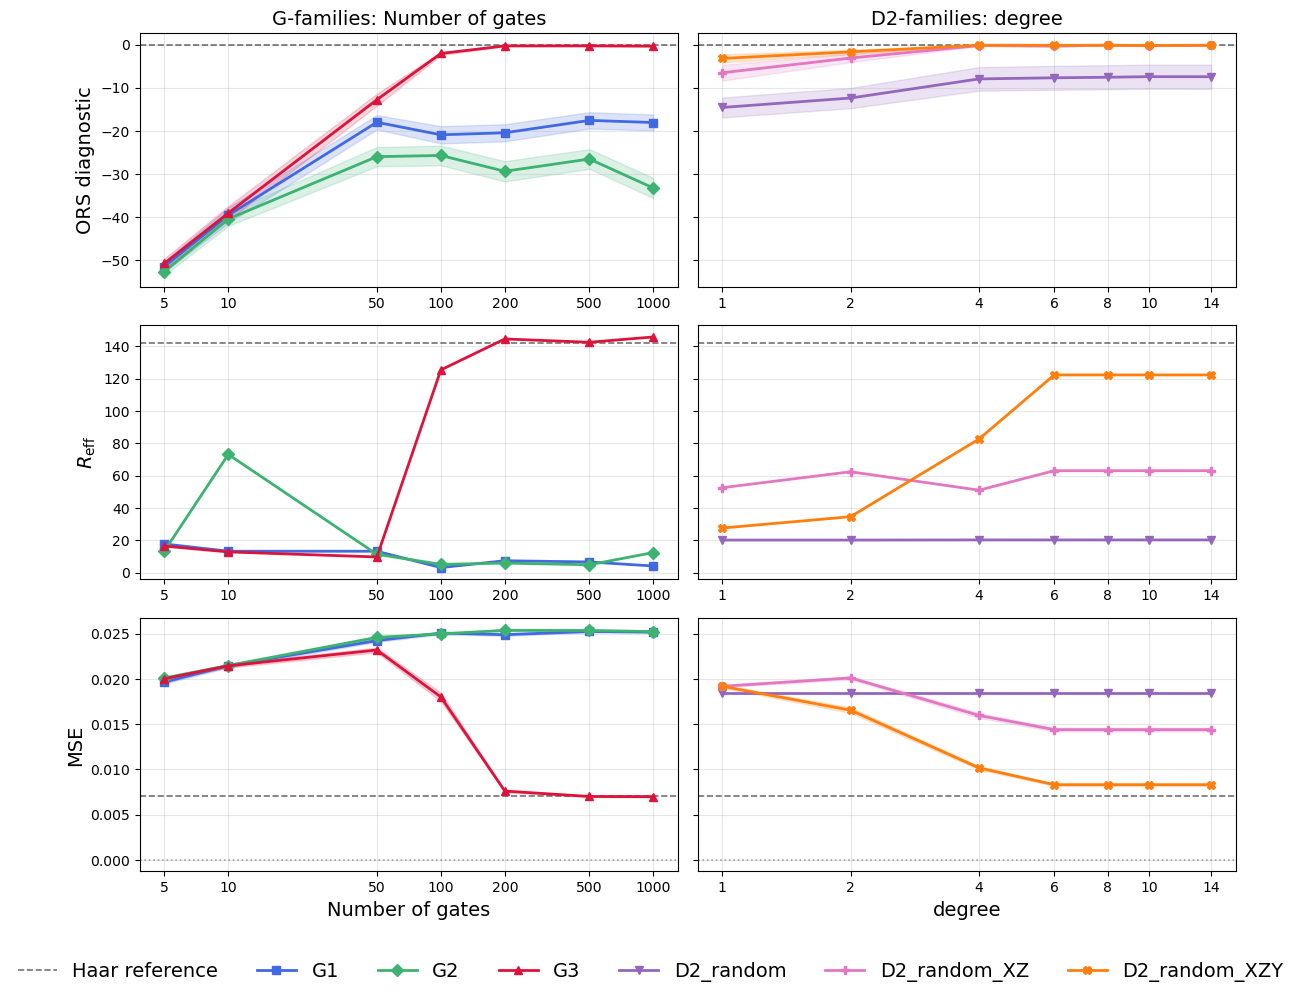

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Helpers for NARMA figure
# ─────────────────────────────────────────────────────────────────────

ors_Haar6 = _ors_haar_value(6, K_idx=1)

def _scalar_stats(res, key, clip_low=None):
    """Mean and SEM of a (ns,) array; clipped if requested."""
    if key not in res:
        return np.nan, np.nan

    vals = np.asarray(res[key])

    if vals.ndim == 2:
        vals = vals[:, -1]

    if clip_low is not None:
        vals = np.clip(vals, clip_low, None)

    ns = len(vals)
    mean = float(np.mean(vals))
    sem = float(np.std(vals) / np.sqrt(ns)) if ns > 1 else 0.0
    return mean, sem


def _haar_scalar(metric_key, clip_low=None):
    if metric_key == "R_eff_e":
        return results_Haar["R_eff_e"]

    m, _ = _scalar_stats(results_Haar, metric_key, clip_low=clip_low)
    return m


def _collect_G(family):
    depths = sorted(results_g[family].keys())

    ors_m, ors_s = [], []
    reff = []
    mse_m, mse_s = [], []

    for d in depths:
        r = results_g[family][d]

        m, s = _scalar_stats(r, "ors", clip_low=ORS_LOWER_CAP)
        ors_m.append(m)
        ors_s.append(s)

        reff.append(r["R_eff_e"])

        m, s = _scalar_stats(r, "mse_e", clip_low=MSE_FLOOR)
        mse_m.append(m)
        mse_s.append(s)

    return (
        np.array(depths),
        np.array(ors_m),
        np.array(ors_s),
        np.array(reff),
        np.array(mse_m),
        np.array(mse_s),
    )


def _collect_D2(
    family,
    results_dict,
    use_multibasis_for_D=True,
    n_ors_D=6,
    K_mb=8,
    B_mb=5,
):
    degs = sorted(results_dict.keys())

    ors_m, ors_s = [], []
    reff = []
    mse_m, mse_s = [], []

    for d in degs:
        r = results_dict[d]

        if use_multibasis_for_D:
            m, s = load_d2_neg_multibasis_ors(
                family=family,
                degree=d,
                n_ors=n_ors_D,
                K_mb=K_mb,
                B=B_mb,
            )
        else:
            m, s = _scalar_stats(r, "ors", clip_low=ORS_LOWER_CAP)

        ors_m.append(m)
        ors_s.append(s)

        reff.append(r["R_eff_e"])

        m, s = _scalar_stats(r, "mse_e", clip_low=MSE_FLOOR)
        mse_m.append(m)
        mse_s.append(s)

    return (
        np.array(degs),
        np.array(ors_m),
        np.array(ors_s),
        np.array(reff),
        np.array(mse_m),
        np.array(mse_s),
    )


# ─────────────────────────────────────────────────────────────────────
# NARMA figure
# ─────────────────────────────────────────────────────────────────────

def fig2_narma(
    save_path=None,
    ors_cap=ORS_LOWER_CAP,
    mse_floor=MSE_FLOOR,
    use_multibasis_for_D=True,
    n_ors_D=6,
    K_mb=8,
    B_mb=5,
):
    """
    G families:
        plot single-basis ORS gap Lambda - Lambda_Haar.

    D families:
        plot -mean(gap_X, gap_Y, gap_Z, gmb_B5).
    """
    if save_path is None:
        save_path = f"figures/fig2_narma_n{nqbits}_D_multibasis.png"

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey="row")

    g_target = ["G1", "G2", "G3"]
    g_data = {fam: _collect_G(fam) for fam in g_target}

    d2_data = {
        "D2_random": _collect_D2(
            "D2_random",
            results_degree,
            use_multibasis_for_D=use_multibasis_for_D,
            n_ors_D=n_ors_D,
            K_mb=K_mb,
            B_mb=B_mb,
        ),
        "D2_random_XZ": _collect_D2(
            "D2_random_XZ",
            globals()["results_degreeXZ"],
            use_multibasis_for_D=use_multibasis_for_D,
            n_ors_D=n_ors_D,
            K_mb=K_mb,
            B_mb=B_mb,
        ),
        "D2_random_XZY": _collect_D2(
            "D2_random_XZY",
            globals()["results_degreeXZY"],
            use_multibasis_for_D=use_multibasis_for_D,
            n_ors_D=n_ors_D,
            K_mb=K_mb,
            B_mb=B_mb,
        ),
    }

    metrics = [
        ("ors",     r"ORS diagnostic"),
        ("R_eff_e", r"$R_{\rm eff}$"),
        ("mse_e",   "MSE"),
    ]

    for row, (key, ylabel) in enumerate(metrics):
        for col in range(2):
            ax = axes[row, col]

            clip_low = ors_cap if key == "ors" else (mse_floor if key == "mse_e" else None)
            href = _haar_scalar(key, clip_low=clip_low) if key != "ors" else 0

            if href is not None and not np.isnan(href):
                ax.axhline(
                    href,
                    color=FAMILY_COLORS["Haar"],
                    ls="--",
                    alpha=0.55,
                    lw=1.2,
                    label="Haar reference" if (row == 0 and col == 0) else None,
                )

            if col == 0:
                families = g_target
                data_src = g_data
            else:
                families = list(d2_data.keys())
                data_src = d2_data

            cs_max = None

            for family in families:
                color = FAMILY_COLORS.get(family, "#888")
                marker = FAMILY_MARKERS.get(family, "o")

                cs, ors_m, ors_s, reff, mse_m, mse_s = data_src[family]

                if len(cs) == 0:
                    continue

                cs_max = cs

                if key == "ors":
                    if col == 1 and use_multibasis_for_D:
                        y = ors_m
                        yerr = ors_s
                    else:
                        y = ors_m - ors_Haar6
                        yerr = ors_s

                    finite = np.isfinite(y) & np.isfinite(yerr)
                    cs_plot = cs[finite]
                    y = y[finite]
                    yerr = yerr[finite]

                    if len(cs_plot) == 0:
                        continue

                    ax.plot(
                        cs_plot,
                        y,
                        marker=marker,
                        color=color,
                        lw=2.0,
                        label=family if row == 0 else None,
                    )

                    ax.fill_between(
                        cs_plot,
                        y - yerr,
                        y + yerr,
                        color=color,
                        alpha=0.18,
                    )

                elif key == "R_eff_e":
                    ax.plot(
                        cs,
                        reff,
                        marker=marker,
                        color=color,
                        lw=2.0,
                        label=family if row == 0 else None,
                    )

                else:
                    ax.plot(
                        cs,
                        mse_m,
                        marker=marker,
                        color=color,
                        lw=2.0,
                        label=family if row == 0 else None,
                    )

                    ax.fill_between(
                        cs,
                        mse_m - mse_s,
                        mse_m + mse_s,
                        color=color,
                        alpha=0.18,
                    )

            ax.set_xscale("log")
            ax.grid(True, which="both", alpha=0.3)

            if cs_max is not None:
                ax.set_xticks(cs_max)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            if row == 0:
                ax.set_title(
                    "G-families: Number of gates" if col == 0 else "D2-families: degree",
                    fontsize=14,
                )

            if row == 2:
                ax.set_xlabel(
                    "Number of gates" if col == 0 else "degree",
                    fontsize=14,
                )

            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

            if key == "mse_e" and mse_floor is not None:
                ax.axhline(mse_floor, color="gray", ls=":", lw=1.2, alpha=0.7)

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=len(labels),
        fontsize=14,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

fig2_narma(
    use_multibasis_for_D=True,
    n_ors_D=6,
    K_mb=4,
    B_mb=5,
)